# 5-C. Feature Decision & RFE — 도메인 지식 반영 및 후진 제거 최종 확정

### 📌 RFE 실험 및 평가 규칙
1. **변수 전수 앱레이션 테스트**: 피처 세트의 크기가 1개가 될 때까지 전체 후진 제거법(RFE) 앱레이션 테스트를 지속하여 최적 지점을 도출합니다.
2. **디스크 단위 롤링 추론 평가 기반 의사결정**: RFE 내부 루프의 매 스텝에서 피처 제거 의사결정은 행 단위 메트릭이 아닌, 실제 운영 방식을 모사한 **디스크 단위 롤링 추론 평가의 PR-AUC** (Recall-Precision 곡선 아래 면적)를 기준으로 수행합니다.
3. **최종 평가에서만 임계값 및 혼동 행렬 도출**: 최적 피처 세트가 선정된 후의 최종 모델 검증 단계에서만 목표 오탐율(FAR 1.0% 상한) 하에서의 운영 임계값 $T$를 설정하고 개체(디스크) 단위 혼동 행렬(Confusion Matrix)과 상세 리드타임 보고서를 작성합니다.


In [1]:
# ── Cell 1: 라이브러리 임포트 및 독립 설정 구역 ───────────────────────
import os
import sys
sys.path.insert(0, os.path.abspath(".."))
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# GPU 가속 지원 여부 동적 체크
import lightgbm as lgb
def check_gpu():
    try:
        lgb.train({'device': 'gpu', 'verbose': -1},
                  lgb.Dataset(np.zeros((1, 1)), label=[0]))
        return True
    except:
        return False

# 한글 폰트 설정
def _set_korean_font():
    candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
    for name in candidates:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()

# ── [독립 설정 클래스] ────────────────────────────────────────
class LocalConfig:
    DATA_ROOT = "../data2"      # 데이터 루트 폴더 (data2)
    TRAIN_PATH = f"{DATA_ROOT}/05_feature_selection/fs_train_filtered.parquet"
    VALIDATION_PATH  = f"{DATA_ROOT}/05_feature_selection/fs_validation_filtered.parquet"

    TARGET_COL = "failure"
    SEED = 42

    # LightGBM 하이퍼파라미터
    LGBM_PARAMS = {
        "objective":              "binary",
        "importance_type":        "gain",
        # "class_weight":           "balanced",
        "max_depth":              7,
        "num_leaves":             60,
        "n_estimators":           300,
        "learning_rate":          0.03,
        "device":                 "gpu" if check_gpu() else "cpu",
        "random_state":           SEED,
        "bagging_seed":           SEED,
        "feature_fraction_seed":  SEED,
        "data_random_seed":       SEED,
        "n_jobs":                 -1,
        "verbose":                -1,
    }

    SHAP_SAMPLE_N = 5000

print("✅ 독립 실행 설정 완료")


c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 독립 실행 설정 완료


In [2]:
# ── 디스크 레벨 평가 헬퍼 함수 (Self-Contained) ───────────────────────
def get_rolling_n_largest(probs: np.ndarray, n: int, W: int) -> float:
    """확률 배열 probs에서 크기가 W인 모든 슬라이딩 윈도우 중 n번째로 큰 값의 최댓값을 반환"""
    if len(probs) < n:
        return 0.0
    if len(probs) < W:
        return np.sort(probs)[-n]
    try:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(probs, W)
        return np.partition(windows, -n, axis=1)[:, -n].max()
    except Exception:
        max_val = 0.0
        for i in range(len(probs) - W + 1):
            window = probs[i:i+W]
            val = np.partition(window, -n)[-n]
            if val > max_val:
                max_val = val
        return max_val

def prepare_disk_level_data(
    df: pd.DataFrame,
    y_prob: np.ndarray,
    target_col: str = "failure",
    serial_col: str = "serial_number",
    date_col: str = "date",
) -> tuple[list[dict], int, int]:
    """Base Serial 단위로 고장/정상 여부 및 예측 확률을 날짜 순서로 그룹화하여 반환."""
    df = df.copy()
    df["y_prob"] = np.asarray(y_prob)
    df["base_serial"] = df[serial_col].str.replace(r'_\\d+$', '', regex=True)
    df = df.sort_values(["base_serial", date_col])
    
    disks_data = []
    for base_serial, grp in df.groupby("base_serial"):
        disks_data.append({
            "base_serial": base_serial,
            "is_failed": int(grp[target_col].max()),
            "probs": grp["y_prob"].values,
            "dates": grp[date_col].values,
            "failures": grp[target_col].values
        })
        
    n_failed = sum(d["is_failed"] for d in disks_data)
    n_normal = len(disks_data) - n_failed
    return disks_data, n_failed, n_normal

def run_disk_level_grid_search(
    disks_data: list[dict],
    thresholds: np.ndarray,
    min_alarms_list: list[int],
    n_failed_disks: int,
    n_normal_disks: int,
    log_dir: str | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> pd.DataFrame:
    """그리드 서치를 벡터화하여 고속 실행하며, window_size에 따른 롤링 윈도우 알림 제약을 지원"""
    import os
    import pandas as pd
    import time
    is_failed_arr = np.array([d['is_failed'] for d in disks_data], dtype=bool)
    nth_probs_matrix = np.zeros((len(disks_data), len(min_alarms_list)))
    
    failed_disks_days = []
    failed_disks_probs = []
    for disk in disks_data:
        if disk['is_failed'] == 1:
            dates = pd.Series(pd.to_datetime(disk['dates']))
            days = (dates.iloc[-1] - dates).dt.days.values
            failed_disks_days.append(days)
            failed_disks_probs.append(disk['probs'])
    
    for idx, disk in enumerate(disks_data):
        probs = disk['probs']
        for n_idx, n in enumerate(min_alarms_list):
            if len(probs) < n:
                nth_probs_matrix[idx, n_idx] = 0.0
            elif window_size is None or window_size <= 0:
                probs_desc = np.sort(probs)[::-1]
                nth_probs_matrix[idx, n_idx] = probs_desc[n - 1]
            else:
                nth_probs_matrix[idx, n_idx] = get_rolling_n_largest(probs, n, window_size)
                
    grid_results = []
    total_combinations = len(min_alarms_list) * len(thresholds)
    count = 0
    t_grid = time.perf_counter()
    
    for n_idx, n in enumerate(min_alarms_list):
        nth_p = nth_probs_matrix[:, n_idx]
        for T in thresholds:
            count += 1
            is_alarmed = (nth_p >= T)
            fps = np.sum(is_alarmed & ~is_failed_arr)
            
            if horizon is not None:
                tps = 0
                for d_days, d_probs in zip(failed_disks_days, failed_disks_probs):
                    idx = np.where(d_probs >= T)[0]
                    if len(idx) >= n:
                        if d_days[idx[n-1]] <= horizon:
                            tps += 1
            else:
                tps = np.sum(is_alarmed & is_failed_arr)
            
            recall = tps / n_failed_disks if n_failed_disks > 0 else 0.0
            far = fps / n_normal_disks if n_normal_disks > 0 else 0.0
            grid_results.append({
                'threshold': T,
                'min_alarms': n,
                'recall': recall,
                'far': far,
                'tps': tps,
                'fps': fps
            })
            
            if count % 500 == 0 or count == total_combinations:
                elapsed = time.perf_counter() - t_grid
                pct = 100.0 * count / total_combinations
                print(f'  ... {count:,}/{total_combinations:,} ({pct:.1f}%) - {elapsed:.1f}s')
                
    df_grid = pd.DataFrame(grid_results)
    return df_grid

def evaluate_detailed_disk_point(
    disks_data: list[dict],
    T: float,
    n: int,
    n_failed_disks: int,
    n_normal_disks: int,
    far_cap: float | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> dict:
    """선택된 단일 운영점에서 세부 지표(Brier Score, 리드타임, Persistence 등) 평가"""
    tps = 0
    fns = 0
    fps = 0
    tns = 0
    lead_times = []
    persistences = []
    fw_hits = []
    density_windows = []
    density_befores = []
    consec_lengths = []
    alert_burdens = []
    
    for disk in disks_data:
        probs = disk['probs']
        failures = disk['failures']
        is_failed = disk['is_failed']
        
        y_pred = (probs >= T).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= n).any())
        else:
            is_alarmed = int(total_alarms >= n)
        
        max_consec = 0; curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec:
                    max_consec = curr_consec
            else:
                curr_consec = 0
        consec_lengths.append(max_consec)
        alert_burdens.append(total_alarms)
        
        if is_failed == 1:
            if is_alarmed == 1:
                if window_size is not None and window_size > 0:
                    trigger_idx = np.where(rolling_alarms >= n)[0][0]
                else:
                    trigger_idx = np.where(y_pred == 1)[0][n - 1]
                trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
                last_date = pd.to_datetime(disk['dates'][-1])
                
                lead_time = (last_date - trigger_date).days
                
                if horizon is not None and lead_time > horizon:
                    fns += 1
                    fw_hits.append(0)
                else:
                    tps += 1
                    lead_times.append(lead_time)
                    
                    alarms_after = y_pred[trigger_idx:].sum()
                    days_after = len(y_pred[trigger_idx:])
                    persistences.append(alarms_after / days_after if days_after > 0 else 0.0)
                    fw_hits.append(1 if y_pred[failures == 1].sum() > 0 else 0)
            else:
                fns += 1
                fw_hits.append(0)
                
            n_fw_rows = (failures == 1).sum()
            n_non_fw_rows = (failures == 0).sum()
            density_windows.append(y_pred[failures == 1].sum() / n_fw_rows if n_fw_rows > 0 else 0.0)
            density_befores.append(y_pred[failures == 0].sum() / n_non_fw_rows if n_non_fw_rows > 0 else 0.0)
        else:
            if is_alarmed == 1:
                fps += 1
            else:
                tns += 1
                
    mean_density_window = np.mean(density_windows) if density_windows else 0.0
    mean_density_before = np.mean(density_befores) if density_befores else 0.0
    max_probs = [np.max(d['probs']) for d in disks_data]
    y_true_disks = [d['is_failed'] for d in disks_data]
    
    res = {
        'threshold': T,
        'min_alarms': n,
        'recall': tps / n_failed_disks if n_failed_disks > 0 else 0.0,
        'far': fps / n_normal_disks if n_normal_disks > 0 else 0.0,
        'precision': tps / (tps + fps) if (tps + fps) > 0 else 0.0,
        'lead_time': np.mean(lead_times) if lead_times else 0.0,
        'persistence': np.mean(persistences) if persistences else 0.0,
        'fw_hit_rate': np.mean(fw_hits) if fw_hits else 0.0,
        'density_ratio': mean_density_window / mean_density_before if mean_density_before > 0 else 0.0,
        'consec_len': np.mean(consec_lengths),
        'alert_burden': np.mean(alert_burdens),
        'calibration': np.mean((np.array(max_probs) - np.array(y_true_disks))**2)
    }
    if far_cap is not None:
        res['far_cap'] = far_cap
    return res

# ── Cell 2: 검증 및 분석/시각화 함수 정의 (Self-Contained) ─────────────
def train_evaluate(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series
) -> dict:
    """
    Train 데이터로 학습하고, Validation 데이터에 대해 디스크 단위 롤링 평가 결과의 PR-AUC를 계산하여 반환합니다.
    """
    # (Inlined functions are defined above)
    from sklearn.metrics import auc
    
    model = LGBMClassifier(**LocalConfig.LGBM_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    
    # X_val의 인덱스를 사용하여 df_validation에서 매칭
    df_eval_temp = pd.DataFrame({
        'serial_number': df_validation.loc[X_val.index, 'serial_number'],
        'date': df_validation.loc[X_val.index, 'date'],
        'failure': y_val
    })
    
    disks_data, n_failed, n_normal = prepare_disk_level_data(df_eval_temp, val_prob)
    
    # 디스크 단위 PR-AUC 계산을 위한 고속 그리드 서치 (임계값 100개 구간)
    thresholds = np.linspace(0.001, 0.999, 100)
    df_grid = run_disk_level_grid_search(
        disks_data, thresholds, [1], n_failed, n_normal,
        log_dir=None, window_size=0, horizon=30
    )
    
    # Recall 정렬 후 Precision 적분을 통한 PR-AUC 구하기
    df_sorted = df_grid.sort_values(by="recall").copy()
    df_sorted["precision"] = df_sorted["tps"] / (df_sorted["tps"] + df_sorted["fps"] + 1e-8)
    df_sorted["precision"] = df_sorted["precision"].fillna(1.0)
    
    disk_prauc = float(auc(df_sorted["recall"].values, df_sorted["precision"].values))
    
    return {
        "prauc": disk_prauc,
        "models": [model],
        "final_model": model,
        "final_validation_pred": val_prob
    }
def plot_gain_importance(models: list[LGBMClassifier], features: list[str], top_n: int = 30) -> pd.DataFrame:
    gain_sum = np.zeros(len(features))
    for m in models:
        imp = m.booster_.feature_importance(importance_type="gain")
        gain_sum += imp
    gain_mean = gain_sum / len(models)
    
    df_imp = pd.DataFrame({"feature": features, "gain": gain_mean}).sort_values("gain", ascending=False).head(top_n).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
    colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(df_imp)))
    ax.barh(df_imp["feature"][::-1], df_imp["gain"][::-1], color=colors[::-1])
    ax.set_xlabel("Mean Gain")
    ax.set_title(f"Gain 기반 Feature 중요도 (Top {top_n})", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return df_imp

def plot_shap_importance(models: list[LGBMClassifier], X_train: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    X_sample = X_train.sample(min(LocalConfig.SHAP_SAMPLE_N, len(X_train)), random_state=LocalConfig.SEED)
    num_cols = X_sample.select_dtypes(include=[np.number]).columns
    X_sample = X_sample.copy()
    X_sample[num_cols] = X_sample[num_cols].astype("float32")

    shap_vals_list = []
    for m in models:
        explainer = shap.TreeExplainer(m)
        sv = explainer.shap_values(X_sample)
        if isinstance(sv, list):
            sv = sv[1]
        shap_vals_list.append(sv)

    shap_mean = np.mean(shap_vals_list, axis=0)
    mean_abs = np.abs(shap_mean).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:top_n]
    X_plot = X_sample.iloc[:, top_idx]
    sv_plot = shap_mean[:, top_idx]

    plt.figure(figsize=(10, max(5, top_n * 0.35)))
    shap.summary_plot(sv_plot, X_plot, show=False, max_display=top_n)
    plt.title(f"SHAP Beeswarm (Top {top_n})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    df_shap = pd.DataFrame({
        "feature": X_sample.columns[top_idx],
        "mean_abs_shap": mean_abs[top_idx]
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    return df_shap

def plot_shap_interaction(models: list[LGBMClassifier], X_train: pd.DataFrame, y_train: pd.Series, top_n: int = 15, sample_n: int = 200) -> pd.DataFrame:
    n = min(sample_n, len(X_train))
    X_s = X_train.sample(n, random_state=LocalConfig.SEED).copy()
    num_cols = X_s.select_dtypes(include=[np.number]).columns
    X_s[num_cols] = X_s[num_cols].astype("float32")

    sv_inter_list = []
    for m in models:
        explainer = shap.TreeExplainer(m)
        sv_inter = explainer.shap_interaction_values(X_s)
        if isinstance(sv_inter, list):
            sv_inter = sv_inter[1]
        sv_inter_list.append(sv_inter)

    mean_inter = np.mean(sv_inter_list, axis=0)
    abs_mean = np.abs(mean_inter).mean(axis=0)
    all_cols = list(X_s.columns)

    diag_vals = np.diag(abs_mean)
    sel_idx = np.argsort(diag_vals)[::-1][:top_n].tolist()
    sel_cols = [all_cols[i] for i in sel_idx]

    feat_names = np.array(sel_cols)
    mat = abs_mean[np.ix_(sel_idx, sel_idx)]
    n_feat = len(feat_names)

    fig, ax = plt.subplots(figsize=(max(8, n_feat * 0.7), max(6, n_feat * 0.7)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto")
    fig.colorbar(im, ax=ax, label="mean |SHAP interaction|")
    ax.set_xticks(range(n_feat))
    ax.set_yticks(range(n_feat))
    ax.set_xticklabels(feat_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(feat_names, fontsize=8)
    ax.set_title(f"SHAP Interaction Matrix (Top {top_n}, sample={n})", fontsize=12, fontweight="bold")

    vmax = mat.max()
    for i in range(n_feat):
        for j in range(n_feat):
            ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", fontsize=max(5, 8 - n_feat // 4),
                    color="white" if vmax > 0 and mat[i, j] > vmax * 0.6 else "black")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(mat, index=feat_names, columns=feat_names)



✅ 헬퍼 함수 및 시각화 함수 로드 완료


In [3]:
# ── Cell 3: [연구자 의사결정 설정] 2단계 피처 지정 ─────────────────
# 05b의 SHAP RFE 시뮬레이션 결과를 토대로 컷오프할 피처 목록과,
# 도메인 지식에 근거하여 필수 보존/추가할 피처 목록을 각각 딕셔너리로 작성하세요.

DECISION_CONFIG = {
    "cutoff_exclude_features": [
        "s191_days_since_last",
        "reallocated_pending_ratio",
        "s242_28d_asfd",
        "s194_28d_mean",
        "total_seeks_diff",
        "s190_28d_std",
        "total_seeks_14d_mean",
        "smart_197_raw",
        "smart_183_raw",
        "smart_184_raw",
        "s187_damaged",
        "s241_diff",
        "s241_14d_mean",
        "s198_28d_max",
        "s242_14d_mean",
        "s187_28d_sum",
        "age_weighted_workload",
        "s187_days_since_first",
        "error_density_14d",
        "smart_241_raw",
        "workload_intensity",
        "smart_242_raw",
        "total_seeks_28d_max",
        "smart_9_raw",
        "smart_198_raw",
        "smart_187_raw",
        "write_stability_ratio",
    ],
    "domain_include_features": [
        # 도메인 지식으로 성능과 관계없이 강제 포함(또는 유지)할 피처 목록을 입력하세요.
        "s187_days_since_first",
        "smart_184_raw",
        "error_density_14d",
        "smart_187_raw",
        "smart_198_raw",
        "total_seeks_28d_asfd",
        "s187_28d_sum",
        "s5_days_since_first",
        "s199_days_since_last",
        "multi_error_count",
        "age_weighted_workload",
        "smart_242_raw",
        "smart_241_raw",
        "smart_9_raw",
        "total_seeks_diff",
        "s241_diff",
        "s194_28d_dai",
        "s194_28d_std",
        "s242_28d_dai",
        "total_reads_7d_asfd",
        "total_reads_7d_max",
        "s194_14d_max",
        "s194_28d_ewma",
        "s194_14d_std",
        "s190_28d_zscore",
        "s190_28d_ewma",
        "s190_28d_mean",
    ]
}

In [4]:
# ── Cell 4: 2단계 피처 세트 정비 ─────────────────────────────────
print("📂 데이터 로드 중...")
df_train = pd.read_parquet(LocalConfig.TRAIN_PATH).sort_values(["serial_number", "date"]).reset_index(drop=True)
df_validation  = pd.read_parquet(LocalConfig.VALIDATION_PATH).sort_values(["serial_number", "date"]).reset_index(drop=True)

y_train = df_train[LocalConfig.TARGET_COL]
y_val  = df_validation[LocalConfig.TARGET_COL]

meta_cols = {"serial_number", "date", LocalConfig.TARGET_COL}
features = [c for c in df_train.columns if c not in meta_cols]
print(f"초기 Feature 개수: {len(features)}")

# 딕셔너리 항목에 있는 애들만 합집합한게 최초 스타트 변수 목록
union_features = set(DECISION_CONFIG["cutoff_exclude_features"]) | set(DECISION_CONFIG["domain_include_features"])
baseline_features = [f for f in features if f in union_features]

# 합집합에 포함되지 않아 제외된 피처 목록 정의 (검증용)
final_cutoff_excludes = [f for f in features if f not in baseline_features]
print(f"-> 최종 컷오프 제외 적용 피처 수: {len(final_cutoff_excludes)}개")
print(f"-> 1차 정비된 Baseline Feature 개수: {len(baseline_features)}")

📂 데이터 로드 중...
초기 Feature 개수: 168
-> 최종 컷오프 제외 적용 피처 수: 126개
-> 1차 정비된 Baseline Feature 개수: 42


In [5]:
# ── Cell 5: 3단계 후진 제거법(RFE) 실행 (SQLite 상태 저장 및 조기 종료 연동) ───────────────────
import sqlite3
import json

print("\n[RFE] 정비된 Baseline 모델 학습 중...")
baseline_res = train_evaluate(df_train[baseline_features], y_train, df_validation[baseline_features], y_val)
baseline_prauc = baseline_res["prauc"]
print(f"-> Baseline Disk PR-AUC: {baseline_prauc:.5f}\n")

# CSV 안전 저장 헬퍼 함수
def save_csv_safe(df, path):
    try:
        df.to_csv(path, index=False)
    except PermissionError:
        print(f"\n⚠️ [경고] '{path}' 파일이 엑셀 등 다른 프로그램에서 열려 있어 업데이트를 건너뜁니다. 파일을 닫아주세요.")
    except Exception as e:
        print(f"\n⚠️ [경고] '{path}' 저장 실패: {e}")

# SQLite DB 초기화 및 진행 테이블 생성
db_path = "rfe_progress.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS rfe_progress (
        step INTEGER PRIMARY KEY,
        removed_feature TEXT,
        remaining_features TEXT,
        prauc REAL
    )
""")
cursor.execute("""
    CREATE TABLE IF NOT EXISTS rfe_trials (
        step INTEGER,
        candidate_feature TEXT,
        prauc REAL,
        PRIMARY KEY (step, candidate_feature)
    )
""")
conn.commit()

# 마지막 진행 상황 확인
cursor.execute("SELECT step, removed_feature, remaining_features, prauc FROM rfe_progress ORDER BY step DESC LIMIT 1")
last_step_row = cursor.fetchone()

if last_step_row:
    step = last_step_row[0] + 1
    prev_score = last_step_row[3]
    current_features = json.loads(last_step_row[2])
    print(f"🔄 기존 RFE 진행 상태를 발견했습니다! Step {step}부터 탐색을 재개합니다.")
    print(f"   -> 남은 피처 수: {len(current_features)}개 | 직전 검증 Disk PR-AUC: {prev_score:.5f}")
else:
    step = 1
    prev_score = baseline_prauc
    current_features = list(baseline_features)
    print("🆕 새로운 RFE 탐색을 시작합니다.")

# 기존 진행 상태 복구하여 rfe_results 리스트 구성
rfe_results = []
rfe_results.append({
    "num_removed": 0,
    "removed_feature": "None (Baseline)",
    "remaining_count": len(baseline_features),
    "prauc": baseline_prauc
})
cursor.execute("SELECT step, removed_feature, remaining_features, prauc FROM rfe_progress ORDER BY step ASC")
for row in cursor.fetchall():
    rfe_results.append({
        "num_removed": row[0],
        "removed_feature": row[1],
        "remaining_count": len(json.loads(row[2])),
        "prauc": row[3]
    })

csv_path = "feature_decision_rfe_results.csv"
trials_csv_path = "feature_decision_rfe_trials.csv"
save_csv_safe(pd.DataFrame(rfe_results), csv_path)

while len(current_features) > 1:
    print(f"\n[Step {step}] 현재 피처 수: {len(current_features)}개 | Baseline Disk PR-AUC: {prev_score:.5f}")
    best_score_this_step = -1.0
    best_feature_to_remove = None
    
    # 각 피처를 하나씩 제거하며 평가
    total_feats = len(current_features)
    for i, f in enumerate(current_features, 1):
        # 이미 이 step에서 이 candidate가 평가되었는지 DB에서 확인
        cursor.execute("SELECT prauc FROM rfe_trials WHERE step = ? AND candidate_feature = ?", (step, f))
        row = cursor.fetchone()
        
        if row is not None:
            score = row[0]
            # 실시간 진행 상황 표시 (복원된 항목 표시)
            print(f"\r   ⏩ [복원] 진행률: [{i}/{total_feats}] | 테스트 피처: '{f}' | 제거 시 Disk PR-AUC: {score:.5f}", end="", flush=True)
        else:
            subset_features = [feat for feat in current_features if feat != f]
            res = train_evaluate(df_train[subset_features], y_train, df_validation[subset_features], y_val)
            score = res["prauc"]
            
            # DB에 개별 시도 결과 기록
            cursor.execute("INSERT OR REPLACE INTO rfe_trials (step, candidate_feature, prauc) VALUES (?, ?, ?)", (step, f, score))
            conn.commit()
            
            # 실시간 진행 상황 표시
            print(f"\r   ⏳ 시뮬레이션 진행률: [{i}/{total_feats}] | 테스트 피처: '{f}' | 제거 시 Disk PR-AUC: {score:.5f}", end="", flush=True)
            
        if score > best_score_this_step:
            best_score_this_step = score
            best_feature_to_remove = f
            
    # 줄바꿈 처리
    print()
    
    # 최적의 피처 제거 확정
    current_features.remove(best_feature_to_remove)
    
    # SQLite DB에 완료 상태 즉시 기록
    cursor.execute("INSERT OR REPLACE INTO rfe_progress (step, removed_feature, remaining_features, prauc) VALUES (?, ?, ?, ?)",
                   (step, best_feature_to_remove, json.dumps(current_features), best_score_this_step))
    conn.commit()
    
    rfe_results.append({
        "num_removed": step,
        "removed_feature": best_feature_to_remove,
        "remaining_count": len(current_features),
        "prauc": best_score_this_step
    })
    
    score_diff = best_score_this_step - prev_score
    diff_sign = "+" if score_diff >= 0 else ""
    print(f"🏆 Step {step} 완료: '{best_feature_to_remove}' 제거 확정")
    print(f"   -> 남은 피처 수: {len(current_features)}개")
    print(f"   -> Disk PR-AUC 변화: {prev_score:.5f} -> {best_score_this_step:.5f} ({diff_sign}{score_diff:.5f})")
    
    save_csv_safe(pd.DataFrame(rfe_results), csv_path)
    
    # 전체 시도(Trials) 로그를 CSV로 저장
    df_trials = pd.read_sql_query("SELECT step, candidate_feature, prauc FROM rfe_trials ORDER BY step ASC, prauc DESC", conn)
    save_csv_safe(df_trials, trials_csv_path)
    
    prev_score = best_score_this_step
    step += 1

conn.close()
df_rfe = pd.DataFrame(rfe_results)
print("\n=== 후진 제거법 최종 결과 ===")
display(df_rfe)



[RFE] 정비된 Baseline 모델 학습 중...
  ... 100/100 (100.0%) - 0.1s
-> Baseline Disk PR-AUC: 0.30492

🆕 새로운 RFE 탐색을 시작합니다.

[Step 1] 현재 피처 수: 42개 | Baseline Disk PR-AUC: 0.30492
  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [1/42] | 테스트 피처: 'smart_184_raw' | 제거 시 Disk PR-AUC: 0.28545  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [2/42] | 테스트 피처: 'smart_187_raw' | 제거 시 Disk PR-AUC: 0.30639  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [3/42] | 테스트 피처: 'smart_197_raw' | 제거 시 Disk PR-AUC: 0.30497  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [4/42] | 테스트 피처: 'smart_198_raw' | 제거 시 Disk PR-AUC: 0.30851  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [5/42] | 테스트 피처: 'smart_9_raw' | 제거 시 Disk PR-AUC: 0.30064  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [6/42] | 테스트 피처: 'smart_241_raw' | 제거 시 Disk PR-AUC: 0.30120  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [7/42] | 테스트 피처: 'smart_242_raw' | 제거 시 Disk PR-AUC: 0.31606  ... 100/100 (100.0%) - 0.1s
   ⏳ 시뮬레이션 진행률: [8/42] | 테스트 피처: 'smart_183_raw' | 제거 시 Dis

,num_removed,removed_feature,remaining_count,prauc
0,0,None (Baseline),42,0.304924
1,1,multi_error_count,41,0.321728
2,2,s241_14d_mean,40,0.324494
3,3,total_reads_7d_asfd,39,0.325786
4,4,s187_damaged,38,0.325798
5,5,s190_28d_zscore,37,0.326290
6,6,smart_197_raw,36,0.326290
7,7,s194_28d_ewma,35,0.326673
8,8,s190_28d_mean,34,0.324028
9,9,total_reads_7d_max,33,0.324926


In [6]:
# ── Cell 6: 최종 데이터셋 필터링 및 업데이트 저장 ───────────────────
# 가장 높은 검증 점수를 보인 시점의 피처 세트를 자동으로 로드하여 저장합니다.
best_row = df_rfe.loc[df_rfe["prauc"].idxmax()]
best_step = int(best_row["num_removed"])
print(f"🏆 최적의 검증 PR-AUC 지점: {best_step}개 제거 (PR-AUC: {best_row['prauc']:.5f})")

# 해당 step까지 제거된 피처 목록
removed_up_to_best = df_rfe.loc[1:best_step, "removed_feature"].tolist() if best_step > 0 else []
final_selected_features = [f for f in baseline_features if f not in removed_up_to_best]
print(f"-> 최종 선택된 피처 개수: {len(final_selected_features)}개")

print("⚠️ 이 노트북은 의사결정 도움 용도로 활용되며, 물리적인 데이터셋 파일 저장(덮어쓰기)은 수행하지 않습니다.")

🏆 최적의 검증 PR-AUC 지점: 27개 제거 (PR-AUC: 0.34239)
-> 최종 선택된 피처 개수: 15개

🧹 드롭 피처 적용 중...
💾 데이터셋 저장 중... (../data2/05_feature_selection/fs_train_filtered.parquet)
✅ 데이터셋 업데이트 및 덮어쓰기 완료!


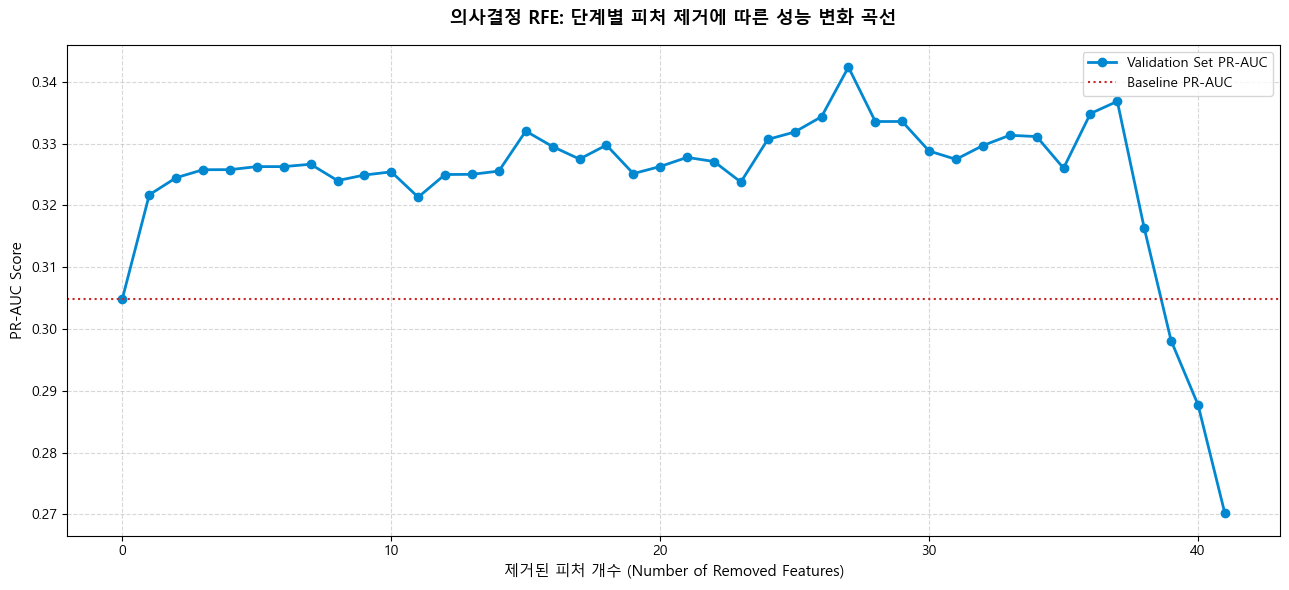

📂 최종 모델 학습 및 시각화용 데이터 연산...
  ... 100/100 (100.0%) - 0.1s

[ 최종 Validation PR-AUC: 0.34219 ]

[ Gain 기반 피처 중요도 시각화 ]


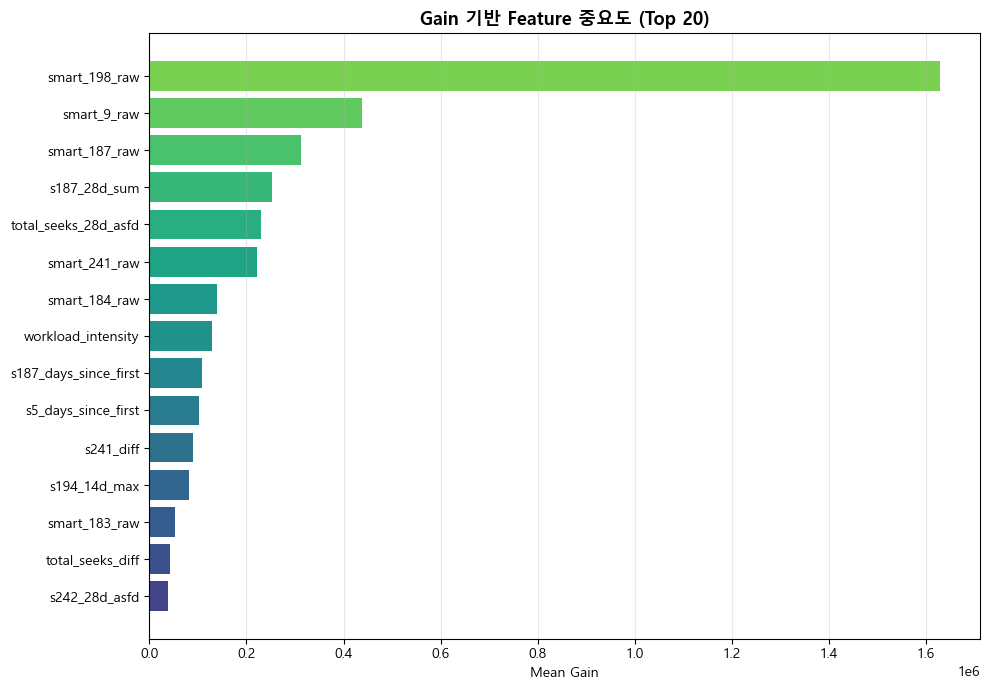


[ SHAP Beeswarm 및 중요도 시각화 ]


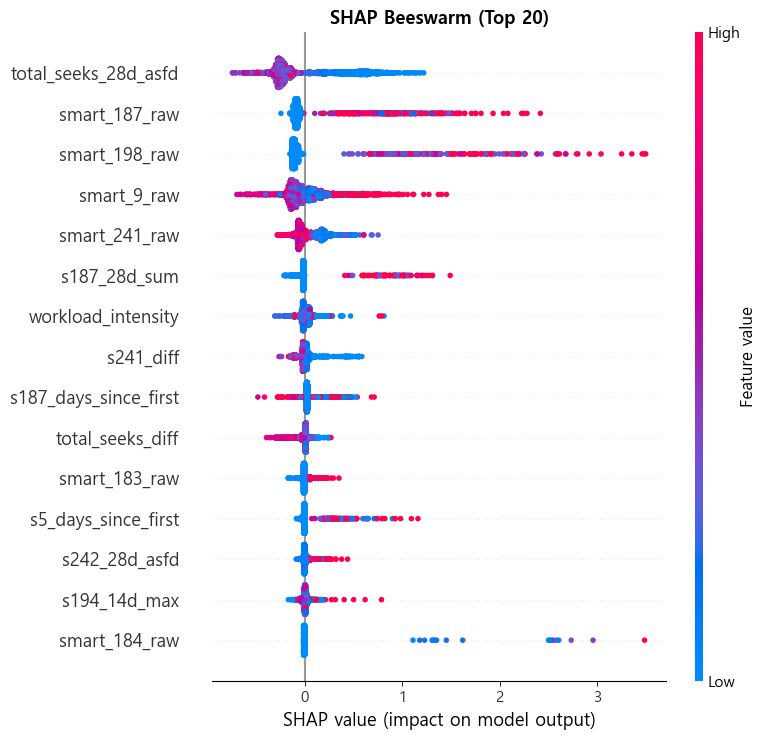


[ SHAP Interaction Matrix 시각화 ]


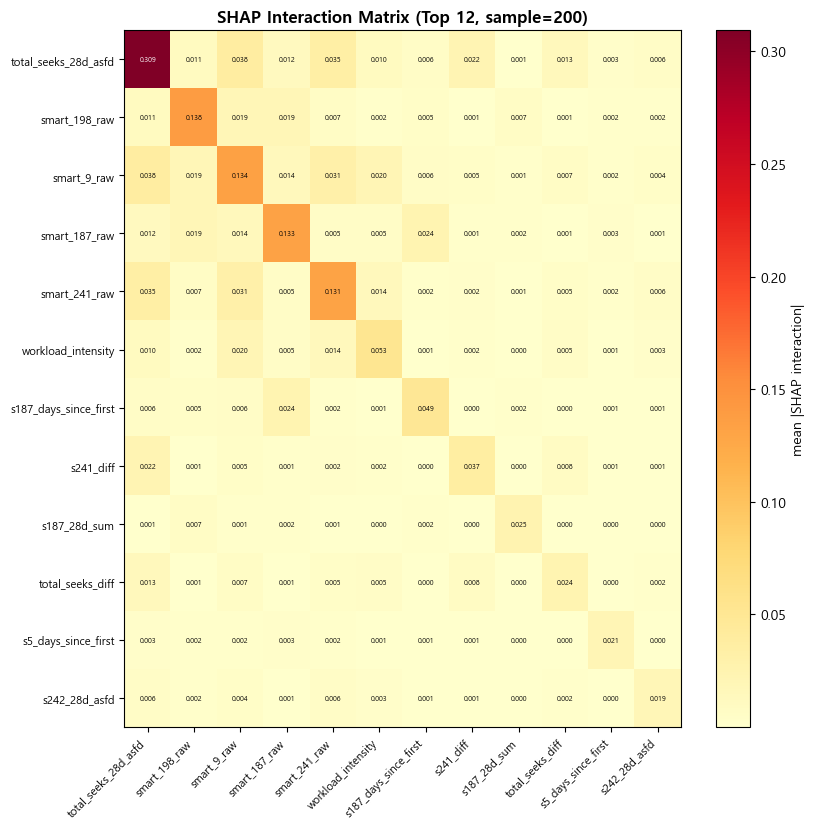


📂 최종 Validation 데이터 개체(디스크) 단위 평가 연산 중...
  ... 500/1,000 (50.0%) - 0.7s
  ... 1,000/1,000 (100.0%) - 1.3s

🎯 [Horizon 30 Days] 최종 적용할 최적 운영점 (FAR 1.0% 상한): 임계값 T = 0.3686 (단일 알람 기준)
  - 디스크 단위 Recall: 28.47%
  - 디스크 단위 FAR: 0.99%
  - 평균 리드타임: 6.0 일
  - 정밀도(Precision): 96.63%

[ Confusion Matrix 시각화 (디스크 단위) ]


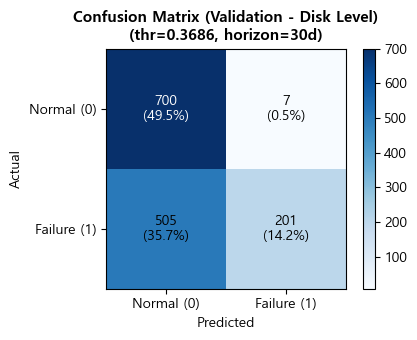

In [7]:
# ── Cell 7: RFE 최종 결과 분석 및 시각화 ─────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# (Inlined functions are used directly)

plt.figure(figsize=(13, 6))
x_indices = np.arange(len(df_rfe))
plt.plot(x_indices, df_rfe["prauc"], marker='o', color='#0288d1', linewidth=2, markersize=6, label='Validation Set PR-AUC')
plt.axhline(baseline_prauc, color='#c62828', linestyle=':', label='Baseline PR-AUC')
plt.title("의사결정 RFE: 단계별 피처 제거에 따른 성능 변화 곡선", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("제거된 피처 개수 (Number of Removed Features)", fontsize=11)
plt.ylabel("PR-AUC Score", fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("📂 최종 모델 학습 및 시각화용 데이터 연산...")
final_res = train_evaluate(df_train_updated[final_selected_features], y_train, df_validation_updated[final_selected_features], y_val)

print(f"\n[ 최종 Validation PR-AUC: {final_res['prauc']:.5f} ]")

print('\n[ Gain 기반 피처 중요도 시각화 ]')
df_gain = plot_gain_importance(final_res["models"], final_selected_features, top_n=20)

print('\n[ SHAP Beeswarm 및 중요도 시각화 ]')
df_shap_res = plot_shap_importance(final_res["models"], df_train_updated[final_selected_features], top_n=20)

print('\n[ SHAP Interaction Matrix 시각화 ]')
df_inter = plot_shap_interaction(final_res["models"], df_train_updated[final_selected_features], y_train, top_n=12, sample_n=200)

print('\n📂 최종 Validation 데이터 개체(디스크) 단위 평가 연산 중...')
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_validation_updated,
    final_res["final_validation_pred"],
    target_col=LocalConfig.TARGET_COL
)

# 30일 Horizon 기준 최적 운영점 (FAR 1.0% 상한) 찾기
thresholds = np.linspace(0.001, 0.999, 1000)
df_grid = run_disk_level_grid_search(
    disks_data, thresholds, [1], n_failed_disks, n_normal_disks,
    log_dir=None, window_size=0, horizon=30
)

# FAR 1.0% 이하 중 Recall이 최대인 지점 선택
sub_grid = df_grid[df_grid['far'] <= 0.01]
if len(sub_grid) > 0:
    best_row = sub_grid.sort_values(by=['recall', 'threshold'], ascending=[False, True]).iloc[0]
    best_T = best_row['threshold']
else:
    best_row = df_grid.sort_values(by='far').iloc[0]
    best_T = best_row['threshold']

print(f"\n🎯 [Horizon 30 Days] 최종 적용할 최적 운영점 (FAR 1.0% 상한): 임계값 T = {best_T:.4f} (단일 알람 기준)")

# 상세 지표 평가
det = evaluate_detailed_disk_point(
    disks_data, best_T, 1, n_failed_disks, n_normal_disks,
    window_size=0, horizon=30
)

print(f"  - 디스크 단위 Recall: {det['recall']*100:.2f}%")
print(f"  - 디스크 단위 FAR: {det['far']*100:.2f}%")
print(f"  - 평균 리드타임: {det.get('lead_time', 0):.1f} 일")
print(f"  - 정밀도(Precision): {det.get('precision', 0)*100:.2f}%")

# Confusion Matrix 계산
tps = round(det['recall'] * n_failed_disks)
fns = n_failed_disks - tps
fps = round(det['far'] * n_normal_disks)
tns = n_normal_disks - fps

def plot_disk_confusion(tps, fns, fps, tns, threshold, title="Confusion Matrix (Validation - Disk Level)"):
    cm = np.array([[tns, fps], [fns, tps]])
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)
    labels = ["Normal (0)", "Failure (1)"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{title}\n(thr={threshold:.4f}, horizon=30d)", fontsize=11, fontweight="bold")
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/total*100:.1f}%)", ha="center", va="center",
                    color="white" if cm[i, j] > total * 0.4 else "black")
    plt.tight_layout()
    plt.show()

print('\n[ Confusion Matrix 시각화 (디스크 단위) ]')
plot_disk_confusion(tps, fns, fps, tns, best_T)

In [ ]:
print('⚠️ [SKIP] 파일 저장을 건너뛰었으므로 최종 정합성 및 무결성 검증을 생략합니다.')